# Transformer for Time Series Forecasting

This notebook builds a small Transformer encoder (positional encoding + multi-head self-attention) from scratch to forecast a synthetic daily time series, then uses it to predict the next 1 year.

**Key idea:** the data has a growing linear trend, and neural nets (including Transformers) don't extrapolate trends well beyond. So we **detrend** the series first — model only the stationary part (seasonality + noise) — and add the trend back after predicting.

In [78]:
import numpy as np               # NumPy: numerical arrays and math operations (used for sine waves, arrays, etc.)
import pandas as pd              # Pandas: tabular / time-indexed data (DataFrames)
import matplotlib.pyplot as plt  # Matplotlib: plotting charts

np.random.seed(42)  # Fix the random seed so the "random" noise we generate is identical every time we re-run this notebook (reproducibility)


In [79]:
# Generate a synthetic daily time series: trend + weekly seasonality + yearly seasonality + noise

n_days = (365*(2026-2010))  # Total days to simulate: 16 years * 365 = 5840 days
dates = pd.date_range(start="2010-01-01", periods=n_days, freq="D")  # 5840 consecutive calendar dates, one per day, starting 2010-01-01

t = np.arange(n_days)  # [0, 1, 2, ..., n_days-1] — a simple "day counter" used as the x-axis for every formula below

trend = 0.05 * t  # A straight line that increases by 0.05 every day (this is what makes the series grow over time)
weekly_seasonality = 5 * np.sin(2 * np.pi * t / 7)        # A wave that repeats every 7 days (period=7), amplitude 5 -> weekly pattern
yearly_seasonality = 15 * np.sin(2 * np.pi * t / 365.25)  # A wave that repeats every ~365.25 days (1 year), amplitude 15 -> yearly pattern
noise = np.random.normal(loc=0, scale=2, size=n_days)     # Random Gaussian noise: mean 0, std-dev 2, one value per day -> real-world randomness

value = 50 + trend + weekly_seasonality + yearly_seasonality + noise  # Combine: baseline 50 + trend + both seasonal waves + noise

df = pd.DataFrame({"date": dates, "value": value})  # Put dates and values into a table (DataFrame)
df.set_index("date", inplace=True)                  # Make "date" the row index instead of a normal column (standard for time series)
print(df.shape)  # (rows, columns) — sanity check: should be (5840, 1)
df.head()          # Show the first 5 rows


(5840, 1)


,value
date,
2010-01-01,50.993428
2010-01-02,53.940652
2010-01-03,56.785988
2010-01-04,56.139244
2010-01-05,48.593606


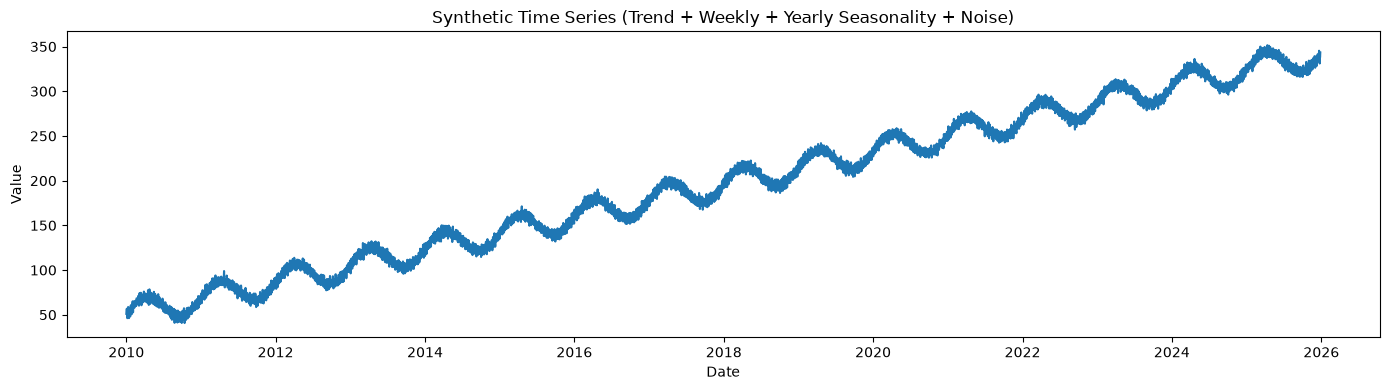

In [80]:
plt.figure(figsize=(14, 4))          # New figure, 14 inches wide, 4 inches tall
plt.plot(df.index, df["value"])      # Plot value (y-axis) against date (x-axis)
plt.title("Synthetic Time Series (Trend + Weekly + Yearly Seasonality + Noise)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()  # Auto-adjust spacing so labels/titles don't get cut off


## Detrend the series

The data has a linear upward trend (`0.05 * day`). If we feed raw values straight into the model, MinMax-scaled test/future values will fall outside the [0, 1] range the model trained on — Transformers (like most NNs) don't extrapolate trends well beyond what they've seen.

**Fix:** fit a straight line to the trend using only the training portion (to avoid leakage), subtract it to get a stationary residual (seasonality + noise), model *that*, and add the trend back after predicting.

In [81]:
# Fit a linear trend on the TRAINING portion only (avoid leakage), then remove it from the whole series

raw_split = int(len(df) * 0.8)   # Index marking 80% of the way through the data: before this = "training", after = "test"
t_idx = np.arange(len(df))        # Day counter [0, 1, ..., 5839], same idea as `t` above, reused here

# np.polyfit fits a polynomial of the given degree using least squares.
# deg=1 means "fit a straight line" (y = slope*x + intercept).
# We only pass in the TRAINING portion (t_idx[:raw_split], value[:raw_split]) so the line
# never "sees" the test period — otherwise that would be data leakage.
trend_coeffs = np.polyfit(t_idx[:raw_split], df["value"].values[:raw_split], deg=1)  # Returns [slope, intercept]

# np.polyval evaluates that fitted line's equation at every day index (0 to 5839), including the test period.
# This is fine — we're applying the line's EQUATION to new x-values, not re-fitting it on test data.
trend_line = np.polyval(trend_coeffs, t_idx)

df["trend"] = trend_line                      # Store the fitted trend line as a new column
df["residual"] = df["value"] - df["trend"]    # Subtract trend from raw value -> what's left is seasonality + noise (no more upward drift)

print(f"Fitted trend: slope={trend_coeffs[0]:.4f}, intercept={trend_coeffs[1]:.2f}")
df[["value", "trend", "residual"]].head()


Fitted trend: slope=0.0496, intercept=50.98


,value,trend,residual
date,,,
2010-01-01,50.993428,50.976483,0.016946
2010-01-02,53.940652,51.026131,2.914522
2010-01-03,56.785988,51.075779,5.710208
2010-01-04,56.139244,51.125427,5.013817
2010-01-05,48.593606,51.175075,-2.581470


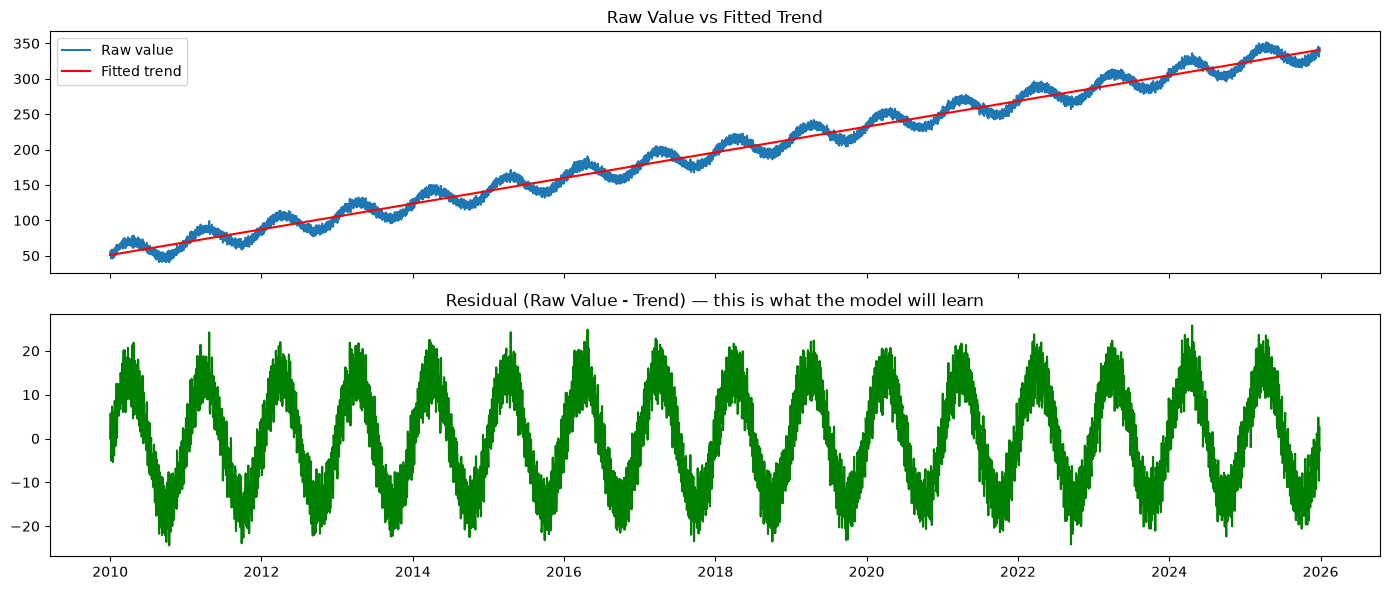

In [82]:
# Sanity check: residual should be flat/stationary (no more upward drift), unlike the raw value

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)  # Figure with 2 stacked subplots sharing the same x-axis (dates)

axes[0].plot(df.index, df["value"], label="Raw value")                  # Top subplot: the original raw series
axes[0].plot(df.index, df["trend"], label="Fitted trend", color="red")  # ...with the fitted trend line overlaid
axes[0].set_title("Raw Value vs Fitted Trend")
axes[0].legend()

axes[1].plot(df.index, df["residual"], color="green")  # Bottom subplot: what's left after removing the trend
axes[1].set_title("Residual (Raw Value - Trend) — this is what the model will learn")
plt.tight_layout()


In [83]:
# Scale the RESIDUAL to [0, 1] — fit the scaler ONLY on the training portion to avoid data leakage
# (fitting on the full series would let the scaler "see" the test period's min/max)

from sklearn.preprocessing import MinMaxScaler  # MinMaxScaler rescales values into [0, 1] using (x - min) / (max - min)

scaler = MinMaxScaler()  # Create the scaler object — it hasn't learned any min/max yet
scaler.fit(df[["residual"]].iloc[:raw_split])          # "fit" = compute min & max, but ONLY looking at the training rows (0 to raw_split)
scaled_values = scaler.transform(df[["residual"]])      # "transform" = apply that min/max formula to the FULL residual series (train + test)


In [84]:
# Create sliding windows: use `window_size` past steps to predict the next step

def create_windows(series, window_size):
    X, y = [], []  # X holds the input windows, y holds the single "next value" target for each window
    for i in range(len(series) - window_size):    # Slide a window across the series, one step at a time
        X.append(series[i:i + window_size])         # Input: window_size consecutive values, e.g. days [i, i+1, ..., i+window_size-1]
        y.append(series[i + window_size])            # Target: the very next value after that window, e.g. day [i+window_size]
    return np.array(X), np.array(y)   # Convert the Python lists into NumPy arrays

window_size = 30   # Use the past 30 days to predict day 31
X, y = create_windows(scaled_values, window_size)
X.shape, y.shape   # X: (num_windows, 30, 1) -> (samples, timesteps, features). y: (num_windows, 1)


((5810, 30, 1), (5810, 1))

In [85]:
# Chronological train/test split (no shuffling for time series)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape

((4648, 30, 1), (1162, 30, 1))

## Build the Transformer

We're modelling the detrended, scaled residual with a small Transformer encoder:
- **Positional encoding** — self-attention has no built-in sense of order, so we inject sin/cos position signals into the input.
- **Multi-head self-attention** — lets each day in the 30-day window attend to every other day in the window.
- **Feedforward + residual + layer norm** — the standard Transformer block, stacked twice here.
- A final pooling + dense head predicts the next day's (scaled) residual.

In [ ]:
# Transformer building blocks

import tensorflow as tf  # TensorFlow: the deep learning framework used to build and train the neural network
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
# Input:                  defines the shape of data going into the model
# Dense:                  a standard fully-connected neural network layer
# Dropout:                randomly "turns off" some neurons during training to prevent overfitting
# LayerNormalization:     normalizes values within each sample so training is more stable
# MultiHeadAttention:     the core Transformer building block — lets the model relate different time steps to each other
# GlobalAveragePooling1D: averages across the time dimension to collapse a sequence into a single vector

from tensorflow.keras.models import Model              # Model: wraps our layers into a trainable Keras model
from tensorflow.keras.callbacks import EarlyStopping   # EarlyStopping: stops training automatically once the model stops improving

def positional_encoding(seq_len, d_model):
    # Self-attention has NO built-in concept of order — if you shuffled the 30 days in a window,
    # attention would treat it the same. Positional encoding injects information about EACH position
    # (day 1, day 2, ... day 30) into the data, using a fixed pattern of sine and cosine waves.

    positions = np.arange(seq_len)[:, np.newaxis]
    # np.arange(seq_len) makes [0, 1, 2, ..., seq_len-1] — one number per time step, a flat 1D array
    # with shape (seq_len,).
    # `[:, np.newaxis]` inserts a new axis in the second position, reshaping it from (seq_len,) to
    # (seq_len, 1) — i.e. turns a flat list into a column vector (seq_len rows, 1 column).
    # We do this so it can be "broadcast" (matched up element-by-element) against `dims` below.

    dims = np.arange(d_model)[np.newaxis, :]


    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    # Computes a different "frequency" for each embedding dimension. Lower dimensions get fast-changing
    # (high frequency) waves, higher dimensions get slow-changing (low frequency) waves — this mix of
    # frequencies is what lets the model tell positions apart later. Shape: (1, d_model).

    angle_rads = positions * angle_rates
    # Multiplies the (seq_len, 1) positions by the (1, d_model) angle_rates. NumPy broadcasts this into
    # a full (seq_len, d_model) matrix: each row = one time step, each column = one embedding dimension,
    # each cell = "position * frequency for that dimension" (in radians).

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  # Every EVEN column (0, 2, 4, ...): apply sine
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  # Every ODD column (1, 3, 5, ...): apply cosine
    # Alternating sine/cosine is the standard Transformer positional-encoding trick — it gives every
    # position a unique, smoothly-varying "fingerprint" across the d_model dimensions.

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)
    # `angle_rads[np.newaxis, ...]` adds a new first dimension (the "batch" dimension), turning shape
    # (seq_len, d_model) into (1, seq_len, d_model). The "..." means "keep every other existing
    # dimension exactly as it is". Keras layers expect a batch dimension, even if it's just size 1
    # (it will automatically broadcast/repeat across however many samples are in the real batch).
    # `tf.cast` converts the NumPy array into a TensorFlow float32 tensor so it can be used inside the model.


In [87]:
# One Transformer encoder block: multi-head self-attention + feedforward, both with residual + layernorm

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # --- Multi-head self-attention sub-layer ---
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    # "Self"-attention: both the query and the key/value are `inputs` itself, meaning every time step
    # looks at every other time step (including itself) in the SAME window to decide what to pay attention to.
    # num_heads = how many independent attention "perspectives" run in parallel.
    # key_dim = the size of each head's internal representation.

    x = Dropout(dropout)(x)  # Randomly zero out some attention outputs during training, to reduce overfitting

    x = LayerNormalization(epsilon=1e-6)(x + inputs)
    # "x + inputs" is a RESIDUAL (skip) connection: we add the original input back to the attention output.
    # This helps gradients flow during training and lets the model default to "pass input through unchanged"
    # if attention isn't helpful for a given case. LayerNormalization then rescales the result for stability.
    # epsilon=1e-6 is a tiny number added during normalization to avoid dividing by zero.

    # --- Feedforward sub-layer ---
    ff = Dense(ff_dim, activation="relu")(x)   # Expand to a larger hidden size (ff_dim) with a ReLU activation
    ff = Dense(inputs.shape[-1])(ff)            # Project back down to the original feature size, so shapes still match for the next residual add
    ff = Dropout(dropout)(ff)                    # Dropout again, for regularization

    return LayerNormalization(epsilon=1e-6)(x + ff)
    # Another residual connection (x + ff) followed by normalization — same pattern as above.


In [88]:
# Build the full Transformer model for time series forecasting

def build_transformer_model(window_size, d_model=32, num_heads=2, ff_dim=64, num_blocks=2, dropout=0.1):
    inputs = Input(shape=(window_size, 1))
    # Defines the expected input shape: window_size time steps, each with 1 feature (our single "residual" value per day)

    x = Dense(d_model)(inputs)
    # Project each day's single value (1 number) up into a richer d_model-dimensional representation (32 numbers).
    # This gives the attention mechanism more "room" to encode useful patterns.

    x = x + positional_encoding(window_size, d_model)
    # Add the fixed sine/cosine positional encoding (same shape as x) so the model knows the ORDER of the days,
    # since attention alone has no built-in sense of sequence order.

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size=d_model // num_heads, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
    # Stack `num_blocks` Transformer encoder blocks one after another (here: 2), each refining the representation further.
    # head_size = d_model // num_heads splits the d_model-sized representation evenly across the attention heads.

    x = GlobalAveragePooling1D()(x)
    # We now have one vector per time step (30 of them). Average them all into a SINGLE vector,
    # collapsing the time dimension so we can make one final prediction.

    x = Dense(32, activation="relu")(x)   # A regular hidden layer to combine the pooled features
    x = Dropout(dropout)(x)                # More regularization
    outputs = Dense(1)(x)                   # Final output: a single number — the predicted (scaled) residual for the next day

    model = Model(inputs, outputs)   # Wrap the input -> output pipeline into a trainable Keras Model
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    # optimizer="adam": the algorithm that updates the model's weights during training
    # loss="mse": Mean Squared Error — what the model tries to minimize (standard choice for regression)
    # metrics=["mae"]: Mean Absolute Error — also tracked for human-readable reporting (not used to update weights)
    return model

model = build_transformer_model(window_size)
model.summary()  # Print a table of every layer, its output shape, and its parameter count


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 30, 32)    │         64 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 30, 32)    │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add_15[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 30, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 30, 32)    │          0 │ dropout_22[0][0], │
│                     │                   │            │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 30, 32)    │      2,080 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 30, 32)    │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 30, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 30, 32)    │          0 │ dropout_25[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 30, 32)    │      2,080 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 30, 32)    │          0 │ dense_25[0][0]  

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, min_delta=0.01)
# monitor="val_loss": watch the validation loss after every epoch
# patience=5: stop if val_loss hasn't improved by at least `min_delta` for 5 epochs in a row
# min_delta=0.01: the minimum improvement in val_loss required to count as "still improving"
# restore_best_weights=True: after stopping, roll the model back to the epoch with the best val_loss (not just the last epoch)

history = model.fit(
    X_train, y_train,                    # Training inputs and targets
    validation_data=(X_test, y_test),    # Data used ONLY to monitor performance each epoch (never used to update weights)
    epochs=1000,                          # Maximum passes over the training data (EarlyStopping will almost certainly stop it much sooner)
    batch_size=64,                        # Number of samples processed before each weight update
    callbacks=[early_stop],               # Attach the EarlyStopping rule defined above
    verbose=1                             # Print a progress bar/log line for every epoch
)
# `history` stores the loss/metric values for every epoch, so we can plot training curves later if we want to.


In [ ]:
# Evaluate on the held-out test set — model predicts the residual, so add the trend back to reconstruct the real value

test_resid_pred_scaled = model.predict(X_test)
# Run the trained model on the test windows. Output shape: (num_test_samples, 1), values still in the
# scaled range (whatever MinMaxScaler produced for the residual).

test_resid_pred = scaler.inverse_transform(test_resid_pred_scaled).flatten()
# inverse_transform undoes the MinMax scaling, converting back to real residual units (not [0,1] anymore).
# .flatten() converts the (num_samples, 1) 2D array into a plain 1D array, easier to work with.

test_dates = df.index[-len(y_test):]
# Grab the actual calendar dates that correspond to the test targets. Since our windows/split are
# chronological, the LAST len(y_test) rows of df line up exactly with the test targets.

test_trend = df["trend"].values[-len(y_test):]
# The (already-fitted) trend value for those same test dates.

test_pred_value = test_resid_pred + test_trend        # residual + trend = reconstructed prediction, in real units
test_actual_value = df["value"].values[-len(y_test):]   # true raw value, for comparison

plt.figure(figsize=(14, 4))
plt.plot(test_dates, test_actual_value, label="Actual")
plt.plot(test_dates, test_pred_value, label="Predicted", color="k")
plt.title("Transformer: Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()


In [ ]:
# Recursive (autoregressive) multi-step forecasting on the residual:
# predict 1 step ahead, slide the window forward with that prediction, repeat.
# Then add the EXTRAPOLATED trend back to get the final forecast in real units.

def forecast_residual(model, last_window, n_steps, window_size):
    window = last_window.copy()
    # Start from the last known 30-day window of scaled residuals. .copy() so we don't
    # accidentally modify the original `scaled_values` array while we update `window` below.

    predictions = []
    for _ in range(n_steps):   # Repeat once per future day we want to forecast
        pred = model.predict(window.reshape(1, window_size, 1), verbose=0)
        # Reshape the flat window into (1, window_size, 1): 1 sample, window_size time steps, 1 feature —
        # this is the exact shape the model expects as input. verbose=0 hides the progress bar.

        predictions.append(pred[0, 0])
        # model.predict returns shape (1, 1) — grab the single scalar value out of it.

        window = np.append(window[1:], pred, axis=0)
        # Slide the window forward by one day: drop the OLDEST value (window[1:], everything except
        # the first row) and append the just-predicted value at the end (axis=0 = "stack it as a new
        # row"). This is what makes the forecast "autoregressive" — each new prediction is based
        # partly on the model's own earlier predictions, not just real historical data.

    return np.array(predictions).reshape(-1, 1)
    # Convert the list of scalars into a NumPy array shaped (n_steps, 1), matching what
    # scaler.inverse_transform() expects.

n_future = 365*3  # How many days ahead to forecast (currently set to 3 years)
last_window = scaled_values[-window_size:]   # The most recent 30 scaled residual values in our dataset — the starting point for forecasting

future_resid_scaled = forecast_residual(model, last_window, n_future, window_size)
future_resid = scaler.inverse_transform(future_resid_scaled).flatten()
# Undo scaling to get the forecasted residuals back in real units, as a flat 1D array.

future_t = np.arange(len(df), len(df) + n_future)
# Day-index counter continuing on from where the historical data left off, e.g. if df has 5840 rows,
# this produces [5840, 5841, ..., 5840+n_future-1] — the "future" days.

future_trend = np.polyval(trend_coeffs, future_t)
# Evaluate the SAME straight-line trend equation (fitted earlier on training data) at these future
# day-indices. This extrapolates the trend forward in time.

future_values = future_resid + future_trend
# Add the model's predicted residual to the extrapolated trend -> final forecast in real units.

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=n_future, freq="D")
# Generate the actual calendar dates for the forecast period, starting the day after our last known date.

future_df = pd.DataFrame({"date": future_dates, "value": future_values}).set_index("date")
# Package the forecast into a DataFrame indexed by date, matching the style of our original `df`.
future_df.head()


In [ ]:
# Plot full history + next-3-year forecast

plt.figure(figsize=(16, 5))
plt.plot(df.index, df["value"], label="Historical")                                    # The full known history
plt.plot(future_df.index, future_df["value"], label="Forecast (Next 3 Year)", color="green")  # The forecasted future
plt.axvline(df.index[-1], color="gray", linestyle="--", linewidth=1)
# Draw a vertical dashed line marking exactly where history ends and forecast begins

plt.title("Transformer Forecast — Next 1 Year")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()


In [ ]:
# Zoomed-in view: last 6 months of history + full forecast (easier to read than the full 16-year plot)

recent_history = df.iloc[-180:]
# .iloc[-180:] selects the last 180 ROWS by position (not by date/label) — roughly the last 6 months of daily data

plt.figure(figsize=(16, 5))
plt.plot(recent_history.index, recent_history["value"], label="Recent History")
plt.plot(future_df.index, future_df["value"], label="Forecast (Next 3 Year)", color="green")
plt.axvline(df.index[-1], color="gray", linestyle="--", linewidth=1)
plt.title("Transformer Forecast — Zoomed In (Last 6 Months + Next 3 Year)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
